# 06 Práctica de laboratorio: Árboles de decisión e interpretabilidad

**Aprendizaje Computacional I**

**Nombre y apellidos:** Miguel Adrian Gheorghe

# Introducción

En esta práctica trabajaremos con **árboles de decisión**, uno de los modelos más interpretables del aprendizaje automático.

Además de entrenar modelos, estudiaremos:

- cómo se construyen los árboles,
- cómo medir la pureza de un nodo,
- el efecto del sobreajuste,
- la poda de árboles,
- la interpretabilidad del modelo,
- y la importancia de las variables.

La práctica está relacionada con los conceptos vistos en teoría: entropía, índice Gini, ganancia de información, profundidad del árbol, sobreajuste y capacidad de generalización.

# Objetivos

Al finalizar esta práctica deberías ser capaz de:

- cargar y preparar un dataset real,
- entrenar árboles de decisión,
- interpretar reglas de decisión,
- comparar entropía y Gini,
- detectar sobreajuste,
- controlar la complejidad del modelo,
- visualizar árboles,
- estudiar importancia de variables,
- comparar entrenamiento y prueba.

# Dataset: Titanic

Trabajaremos con una versión del famoso dataset del Titanic.

El objetivo será predecir si un pasajero sobrevivió o no al naufragio utilizando información como edad, sexo, clase del billete, tarifa pagada y número de familiares a bordo.

# Librerías necesarias

Ejecuta la siguiente celda.

In [32]:
# Librerías básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset
from sklearn.datasets import fetch_openml

# División entrenamiento/prueba
from sklearn.model_selection import train_test_split, cross_val_score

# Árboles
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (8, 6)

# Código de estudiante

## Ejercicio 1

Introduce tu código de estudiante.

In [33]:
CODIGO_ESTUDIANTE = 40

np.random.seed(CODIGO_ESTUDIANTE)

# Carga del dataset

## Ejercicio 2

Carga el dataset Titanic usando `fetch_openml`.

In [34]:
# COMPLETAR
titanic = fetch_openml("titanic", version=1, as_frame=True)
df = pd.DataFrame(data=titanic.data, columns=titanic.feature_names)
df["survived"] = titanic.target
df["survived"] = df["survived"].astype(int)

## Ejercicio 3

Muestra:

- las primeras filas,
- el número de ejemplos,
- las columnas del dataset.

In [35]:
# COMPLETAR
print(f"Primeras filas:")
display(df.head())
print(f"Número de muestras: {df.shape[0]}")
print(f"Columnas: {df.columns}")

Primeras filas:


,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0


Número de muestras: 1309
Columnas: Index(['pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare',
       'cabin', 'embarked', 'boat', 'body', 'home.dest', 'survived'],
      dtype='str')


# Selección y preparación de variables

## Ejercicio 4

Selecciona las siguientes variables:

- `pclass`
- `sex`
- `age`
- `sibsp`
- `parch`
- `fare`

La variable objetivo será:

- `survived`

In [36]:
# COMPLETAR
df = df[["pclass", "sex", "age", "sibsp", "parch", "fare", "survived"]].copy()

## Ejercicio 5

Estudia los valores perdidos del dataset.

Pregunta:

1. ¿Qué variable tiene más valores ausentes?
2. ¿Por qué crees que esto ocurre?

In [37]:
# COMPLETAR
df.isna().sum()

pclass        0
sex           0
age         263
sibsp         0
parch         0
fare          1
survived      0
dtype: int64

**Respuesta.**

La variable de edad, debido a que los registros eran incompletos y que gran parte de la documentación física se perdió bajo el agua y no es posible saber la edad.

## Ejercicio 6

Elimina las filas con valores perdidos.

Después muestra el nuevo tamaño del dataset.

In [38]:
# COMPLETAR
df = df.drop_duplicates()
print(f"Número de muestras: {df.shape[0]}")

Número de muestras: 1108


## Ejercicio 7

Convierte la variable categórica `sex` a valores numéricos.

Sugerencia:

- male → 0
- female → 1

In [39]:
# COMPLETAR
df["sex"] = df["sex"].map({"male": 0, "female": 1})

# Exploración inicial

## Ejercicio 8

Representa el número de supervivientes y no supervivientes.

In [40]:
# COMPLETAR
df["survived"].value_counts()

survived
0    642
1    466
Name: count, dtype: int64

## Ejercicio 9

Calcula el porcentaje de supervivencia de hombres y mujeres. Muestra una figura.

Pregunta:

- ¿Qué diferencias observas?

Porcentaje de supervivencia: sex
1    73.193473
0    22.385862
Name: survived, dtype: float64


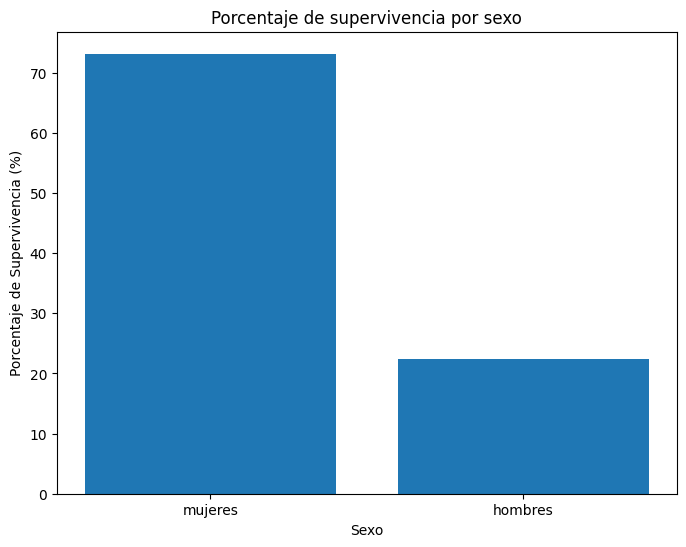

In [41]:
# COMPLETAR
porcentajes = df.groupby("sex")["survived"].mean() * 100
print(f"Porcentaje de supervivencia: {porcentajes}")

plt.bar(["mujeres", "hombres"], porcentajes)
plt.title("Porcentaje de supervivencia por sexo")
plt.xlabel("Sexo")
plt.ylabel("Porcentaje de Supervivencia (%)")
plt.show()

**Respuesta.**

El porcentaje de mujeres es del 73%. Eso se debe a que a la hora de evacuar iban primero las mujeres y los hijos, es por ello que ese porcentaje es alto a diferencia de los hombres con un 22%.

# División entrenamiento/prueba

## Ejercicio 10

Divide los datos en entrenamiento (80%) y prueba (20%).

Usa `random_state = CODIGO_ESTUDIANTE` y `stratify = y`.

In [42]:
# COMPLETAR
X_train, X_test, y_train, y_test = train_test_split(
    df.drop("survived", axis=1),
    df["survived"],
    train_size=0.8,
    test_size=0.2,
    random_state=CODIGO_ESTUDIANTE,
    stratify=df["survived"]
)

# Primer árbol de decisión

## Ejercicio 11

Entrena un árbol de decisión usando criterio `gini` y profundidad máxima 3.

In [43]:
# COMPLETAR
ad = DecisionTreeClassifier(criterion="gini", max_depth=3)
ad.fit(X_train, y_train)
y_pred = ad.predict(X_test)

## Ejercicio 12

Calcula accuracy, precision, recall y F1-score. Toma como clase positiva `survived = 1`, es decir, sobrevivió.

In [44]:
# COMPLETAR
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.7523
Precision: 0.7111
Recall: 0.6882
F1-score: 0.6995


## Ejercicio 13

Construye la matriz de confusión con `confusion_matrix`.

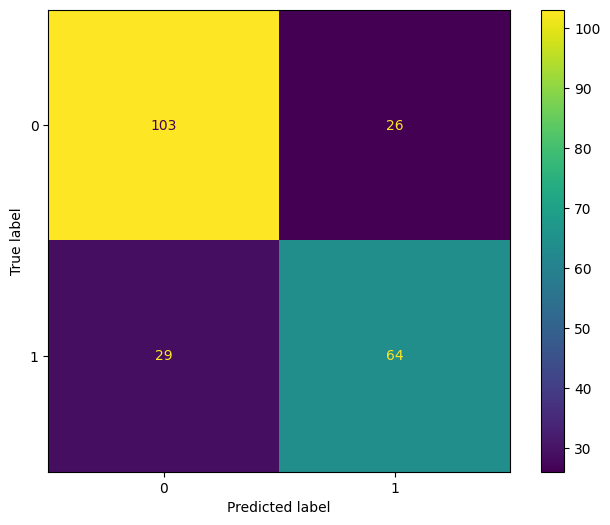

In [45]:
# COMPLETAR
cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm)

cmd.plot()
plt.show()

# Visualización e interpretación del árbol

## Ejercicio 14

Representa gráficamente el árbol con `plot_tree`.

[Text(0.5, 0.875, 'sex <= 0.5\ngini = 0.488\nsamples = 886\nvalue = [513, 373]\nclass = Muere'),
 Text(0.25, 0.625, 'age <= 9.5\ngini = 0.34\nsamples = 539\nvalue = [422, 117]\nclass = Muere'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'sibsp <= 2.5\ngini = 0.487\nsamples = 31\nvalue = [13, 18]\nclass = Sobrevive'),
 Text(0.0625, 0.125, 'gini = 0.0\nsamples = 18\nvalue = [0, 18]\nclass = Sobrevive'),
 Text(0.1875, 0.125, 'gini = 0.0\nsamples = 13\nvalue = [13, 0]\nclass = Muere'),
 Text(0.375, 0.375, 'pclass <= 1.5\ngini = 0.314\nsamples = 508\nvalue = [409, 99]\nclass = Muere'),
 Text(0.3125, 0.125, 'gini = 0.454\nsamples = 138\nvalue = [90, 48]\nclass = Muere'),
 Text(0.4375, 0.125, 'gini = 0.238\nsamples = 370\nvalue = [319, 51]\nclass = Muere'),
 Text(0.75, 0.625, 'pclass <= 2.5\ngini = 0.387\nsamples = 347\nvalue = [91.0, 256.0]\nclass = Sobrevive'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'fare <= 22.0\ngini = 0.117\nsamples = 192\nvalue = [12, 180]\nclass = So

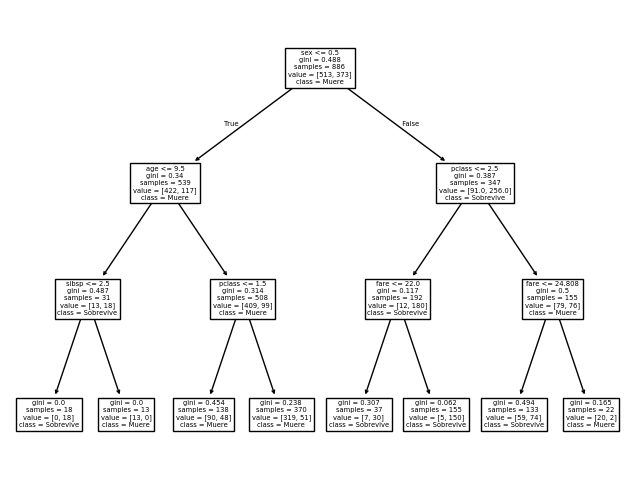

In [46]:
# COMPLETAR
plot_tree(
    ad, 
    feature_names=df.drop("survived", axis=1).columns, # Cambia por tus columnas reales
    class_names=['Muere', 'Sobrevive']
)

## Ejercicio 15

Muestra las reglas del árbol en formato texto con `export_text`.

In [47]:
# COMPLETAR
print(export_text(
    ad,
    feature_names=df.drop("survived", axis=1).columns,
))

|--- sex <= 0.50
|   |--- age <= 9.50
|   |   |--- sibsp <= 2.50
|   |   |   |--- class: 1
|   |   |--- sibsp >  2.50
|   |   |   |--- class: 0
|   |--- age >  9.50
|   |   |--- pclass <= 1.50
|   |   |   |--- class: 0
|   |   |--- pclass >  1.50
|   |   |   |--- class: 0
|--- sex >  0.50
|   |--- pclass <= 2.50
|   |   |--- fare <= 22.00
|   |   |   |--- class: 1
|   |   |--- fare >  22.00
|   |   |   |--- class: 1
|   |--- pclass >  2.50
|   |   |--- fare <= 24.81
|   |   |   |--- class: 1
|   |   |--- fare >  24.81
|   |   |   |--- class: 0



## Ejercicio 16

Pregunta:

1. ¿Qué variable aparece en la raíz?
2. ¿Tiene sentido desde el punto de vista del problema?
3. ¿Qué grupos parecen tener mayor supervivencia?

**Respuesta.**

1. En la raíz del árbol aparece la variable sex <= 0.50.
2. Tiene todo el sentido del mundo. El algoritmo selecciona en la raíz la variable que genera la mayor ganancia de información. La orden de evacuación del barco priorizó estrictamente a "mujeres y niños primero", convirtiendo al sexo del pasajero en el factor predictivo más determinante y con mayor impacto en la supervivencia.
3. Mujeres de primera y segunda clase y niños.

# Entropía frente a índice Gini

## Ejercicio 17

Entrena otro árbol utilizando criterio `entropy` y la misma profundidad máxima.

In [48]:
# COMPLETAR
ad_entropy = DecisionTreeClassifier(criterion="entropy", max_depth=3)
ad_entropy.fit(X_train, y_train)
y_pred = ad_entropy.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.7477
Precision: 0.7033
Recall: 0.6882
F1-score: 0.6957


## Ejercicio 18

Compara los resultados obtenidos con `gini` y `entropy`.

Pregunta:

- ¿Las diferencias son grandes o pequeñas?

**Respuesta.**

La diferencia es apenas notable. Gini y Entropía dan casi los mismos resultados porque ambas fórmulas miden lo mismo: la impureza o desorden de los datos en cada nodo.

# Sobreajuste

## Ejercicio 19

Entrena varios árboles con distintas profundidades máximas:

$$
max\_depth \in \{1,2,3,4,5,6,8,10,None\}
$$

Calcula accuracy en entrenamiento y accuracy en prueba.

In [49]:
# COMPLETAR
max_depth = [1, 2, 3, 4, 5, 6, 8, 10, None]
resultados = []

for m in max_depth:
    model = DecisionTreeClassifier(criterion="gini", max_depth=m)
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_pred_train)
    
    y_pred_test = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred_test)

    resultados.append({
        "max_depth": m,
        "Acc Train": train_acc,
        "Acc Test": test_acc
    })

## Ejercicio 20

Representa gráficamente accuracy entrenamiento y accuracy prueba frente a la profundidad máxima.

,max_depth,Acc Train,Acc Test
0,1.0,0.765237,0.734234
1,2.0,0.774266,0.770270
2,3.0,0.805869,0.752252
3,4.0,0.806998,0.752252
4,5.0,0.820542,0.761261
5,6.0,0.851016,0.747748
6,8.0,0.876975,0.743243
7,10.0,0.914221,0.702703
8,NaN,0.974041,0.675676


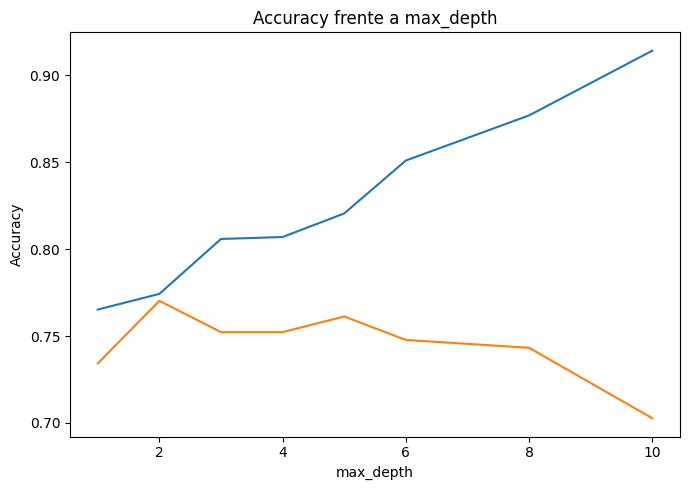

In [50]:
# COMPLETAR

df_resultados = pd.DataFrame(resultados)
display(df_resultados)

plt.figure(figsize=(7, 5))
plt.plot(df_resultados["max_depth"], df_resultados["Acc Train"])
plt.plot(df_resultados["max_depth"], df_resultados["Acc Test"])

plt.title("Accuracy frente a max_depth")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

## Ejercicio 21

Pregunta:

1. ¿Qué ocurre para profundidades muy grandes?
2. ¿Dónde parece producirse sobreajuste?
3. ¿Por qué un árbol muy profundo puede generalizar peor?

**Respuesta.**

1. El árbol empieza a memorizar los datos de entrenamiento, haciendo que el Train Accuracy roce el 100%, mientras que el Test Accuracy empieza a caer notablemente.

2. Dónde se produce el sobreajuste: El sobreajuste (overfitting) se manifiesta a partir de profundidades como 4 y más grandes, justo en el punto donde la curva de prueba se separa de la de entrenamiento y empieza a empeorar.

3. Un árbol extremadamente profundo genera demasiadas ramificaciones específicas y complejas, perdiendo su capacidad de abstracción. En lugar de aprender los patrones generales y lógicos del Titanic, termina aprendiendo el ruido, las anomalías y las excepciones particulares del conjunto de entrenamiento, fallando por completo al enfrentarse a datos nuevos.

# Poda y control de complejidad

## Ejercicio 22

Entrena un árbol restringiendo `min_samples_leaf = 10`.

Compara profundidad, número de nodos y accuracy.

In [51]:
# COMPLETAR
ad_leaf = DecisionTreeClassifier(min_samples_leaf=10)
ad_leaf.fit(X_train, y_train)
y_pred = ad_leaf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7387


## Ejercicio 23

Pregunta:

- ¿Por qué imponer restricciones puede mejorar la generalización?

**Respuesta.**

Imponer restricciones mejora la generalización porque actúa como un "freno de mano" que evita que el árbol se vuelva demasiado complejo. Al prohibirle crear ramas infinitas para explicar cada pequeña excepción o caso raro del dataset, obligamos al algoritmo a quedarse únicamente con las tendencias más grandes, lógicas y generales del problema.

# Importancia de variables

## Ejercicio 24

Obtén la importancia de las variables usando `feature_importances_`.

In [52]:
# COMPLETAR
importancias = ad.feature_importances_

df_importancias = pd.DataFrame({
    "Variable": X_train.columns, 
    "Importancia": importancias
})

# Mostrar los resultados ordenados de mayor a menor
display(df_importancias)

,Variable,Importancia
0,pclass,0.225906
1,sex,0.599057
2,age,0.045511
3,sibsp,0.079012
4,parch,0.000000
5,fare,0.050514


## Ejercicio 25

Representa gráficamente la importancia de variables.

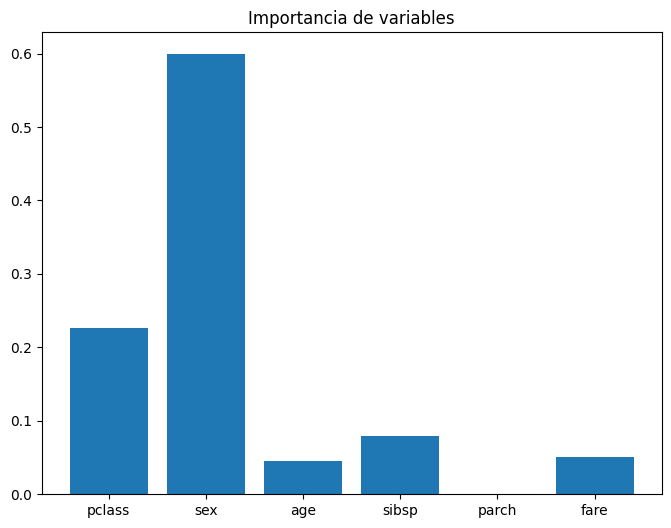

In [53]:
# COMPLETAR
plt.bar(df_importancias["Variable"], df_importancias["Importancia"])
plt.title("Importancia de variables")
plt.show()

## Ejercicio 26

Pregunta:

1. ¿Qué variables parecen más importantes?
2. ¿Coincide con lo observado en el árbol?
3. ¿Qué limitaciones tiene esta medida de importancia?

**Respuesta.**

1. El sexo (sex) es la variable más importante con un 60%, seguida por la clase del billete 22.5%. Las variables numéricas y familiares (sibsp, fare y age) tienen un peso muy secundario.
2. Sí, coincide plenamente porque el algoritmo calcula la importancia según cuánta impureza de Gini reduce cada variable. Como sex está en la raíz y divide al $100\%$ de los pasajeros, y pclass se usa inmediatamente después en un nodo muy grande, es lógico que registren los valores más altos.
3. Esta métrica tiende a inflar la importancia de variables continuas con muchos valores únicos (como fare o age) porque ofrecen más opciones de división. Además, si dos variables están muy correlacionadas (como clase alta y precio de billete caro), el árbol elegirá una y camuflará la verdadera relevancia de la otra.

# Validación cruzada

## Ejercicio 27

Utiliza validación cruzada de 5 particiones para estimar el rendimiento medio de un árbol.

In [54]:
# COMPLETAR

# 2. Aplicar cross_val_score (cv=5 indica las 5 particiones)
scores = cross_val_score(ad, df.drop("survived", axis=1), df["survived"], cv=5, scoring="accuracy")

# 3. Mostrar los resultados
print(f"Accuracy de cada partición: {scores}")
print(f"Accuracy medio estimado: {scores.mean():.4f}")

Accuracy de cada partición: [0.48198198 0.80630631 0.74774775 0.7239819  0.58371041]
Accuracy medio estimado: 0.6687


## Ejercicio 28

Pregunta:

- ¿Por qué la validación cruzada suele ser más fiable que una sola partición entrenamiento/prueba?

**Respuesta.**

Porque evalúa el modelo en múltiples combinaciones de datos en lugar de depender del "azar" de una sola división. Esto evita que el rendimiento estimado se vea distorsionado por una partición de prueba inusualmente fácil o difícil. Al asegurar que cada pasajero del Titanic sea utilizado tanto para entrenar como para testear, ofrece una estimación matemática mucho más realista, robusta y estable de cómo generalizará el modelo con datos futuros.

# Comparación final de modelos

## Ejercicio 29

Construye una tabla resumen comparando varios modelos.

Incluye al menos: criterio, profundidad máxima, accuracy, precision, recall y F1-score.

In [55]:
# COMPLETAR
configuraciones = [
    {"Nombre": "Árbol Inicial", "criterio": "gini", "depth": 4},
    {"Nombre": "Árbol Entropía", "criterio": "entropy", "depth": 4},
    {"Nombre": "Árbol Restringido (Óptimo)", "criterio": "gini", "depth": 3},
    {"Nombre": "Árbol Sobreajustado", "criterio": "gini", "depth": None}
]

filas_resumen = []

for config in configuraciones:
    ad = DecisionTreeClassifier(
        criterion=config["criterio"], 
        max_depth=config["depth"], 
        random_state=42
    )
    
    ad.fit(X_train, y_train)
    
    y_pred = ad.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    filas_resumen.append({
        "Modelo": config["Nombre"],
        "Criterio": config["criterio"].capitalize(),
        "Max Depth": str(config["depth"]),
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1
    })

df_comparativa = pd.DataFrame(filas_resumen)

print(df_comparativa.to_string(index=False, formatters={
    "Accuracy": "{:,.4f}".format,
    "Precision": "{:,.4f}".format,
    "Recall": "{:,.4f}".format,
    "F1-score": "{:,.4f}".format
}))

                    Modelo Criterio Max Depth Accuracy Precision Recall F1-score
             Árbol Inicial     Gini         4   0.7523    0.7111 0.6882   0.6995
            Árbol Entropía  Entropy         4   0.7477    0.7033 0.6882   0.6957
Árbol Restringido (Óptimo)     Gini         3   0.7523    0.7111 0.6882   0.6995
       Árbol Sobreajustado     Gini      None   0.6802    0.6078 0.6667   0.6359


# Ejercicio final de reflexión

Responde brevemente a las siguientes preguntas.

1. ¿Qué ventajas tienen los árboles de decisión?
2. ¿Qué inconvenientes tienen?
3. ¿Por qué los árboles profundos tienden a sobreajustar?
4. ¿Qué diferencia existe entre entropía e índice Gini?
5. ¿Por qué los árboles son considerados modelos interpretables?
6. ¿Qué importancia tiene controlar la complejidad del modelo?
7. ¿Qué ventajas tiene la validación cruzada?

**Respuesta.**

1. Son muy fáciles de entender y visualizar, requieren muy poca preparación o escalado de los datos, y pueden manejar tanto variables numéricas como categóricas sin problemas. Además, seleccionan automáticamente las variables más importantes del problema de forma nativa.
2. Su principal defecto es la alta inestabilidad o varianza: pequeños cambios en los datos de entrenamiento pueden generar un árbol completamente diferente. También tienden con mucha facilidad al sobreajuste si no se limitan, y les cuesta modelar relaciones lineales continuas complejas.
3. Porque cuanta más profundidad tienen, más nodos y divisiones crean, lo que les permite segmentar los datos en grupos cada vez más pequeños y específicos. Al final, en lugar de aprender el patrón general, terminan memorizando el ruido y las excepciones del conjunto de entrenamiento.
4. Ambos miden la impureza de un nodo, pero cambian en su fórmula matemática: el índice Gini se basa en probabilidades cuadráticas, mientras que la Entropía utiliza una función logarítmica. En la práctica, ofrecen casi siempre los mismos resultados porque ambas curvas trazan la misma forma de campana.
5. Se les llama modelos de "caja blanca" porque sus decisiones imitan perfectamente el razonamiento humano a través de reglas lógicas secuenciales. Se puede rastrear el camino exacto que ha seguido el algoritmo paso a paso desde la raíz hasta la hoja para entender el porqué de cada predicción.
6. Controlar la complejidad es vital para encontrar el equilibrio perfecto entre sesgo y varianza. Al frenar el crecimiento del árbol, evitamos el sobreajuste y forzamos al algoritmo a quedarse únicamente con las tendencias más estables y reales del dataset, lo que optimiza y mejora su rendimiento con datos futuros.
7. Ofrece una estimación del rendimiento del modelo mucho más robusta, realista y fiable que una sola partición estática de entrenamiento/prueba. Al rotar los datos en varias particiones y asegurar que cada fila se evalúe al menos una vez, elimina el factor "suerte" en la división de los datos y reduce drásticamente la varianza de la evaluación.

# Entrega

La entrega debe incluir el notebook completado, todas las gráficas, respuestas razonadas e interpretación de resultados.

No basta con ejecutar código: las respuestas deben explicar qué significan los resultados obtenidos.

# Comentario sobre el código de estudiante

Todos los estudiantes trabajarán con el mismo dataset completo, pero usarán distintos valores de `random_state` derivados de su código de estudiante.

Esto hace que las particiones entrenamiento/prueba cambien ligeramente y los resultados numéricos no sean exactamente iguales, pero todos trabajan sobre el mismo problema y pueden compararse resultados.